# NASA CMAPSS — Exploratory Data Analysis

The focus here is on:

- dataset structure and engine counts
- missing values and constant sensors
- engine lifetime and RUL distributions
- sensor behaviour over an engine's lifetime
- relationships between sensors and RUL
- the effect of the project's feature-engineering steps

Model training, tuning, inference and final evaluation are handled by the Python pipeline in `src/`. This notebook is mainly for exploration and documenting the reasoning behind the features used by the model.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if not (PROJECT_ROOT / "configs" / "config.yaml").exists():
    raise FileNotFoundError(
        "Project root was not found. Run this notebook from the project root "
        "or from the notebooks/ directory."
    )

sys.path.insert(0, str(PROJECT_ROOT))

from src.data.ingestion import load_training_data
from src.features.feature_engineering import (
    remove_constant_columns,
    create_operating_condition,
    add_lag_features,
    add_rolling_features,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

plt.rcParams["figure.figsize"] = (10, 5)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\parde\Downloads\predictive_maintenance_RUL


## 2. Load the training data

In [2]:
df = load_training_data()

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

df.head()

2026-09-18 01:57:56,961 | INFO | Loading dataset train_FD001.txt
2026-09-18 01:57:57,075 | INFO | Loaded 20,631 rows from train_FD001.txt
2026-09-18 01:57:57,077 | INFO | Loading dataset train_FD002.txt
2026-09-18 01:57:57,251 | INFO | Loaded 53,759 rows from train_FD002.txt
2026-09-18 01:57:57,251 | INFO | Loading dataset train_FD003.txt
2026-09-18 01:57:57,367 | INFO | Loaded 24,720 rows from train_FD003.txt
2026-09-18 01:57:57,367 | INFO | Loading dataset train_FD004.txt
2026-09-18 01:57:57,557 | INFO | Loaded 61,249 rows from train_FD004.txt
2026-09-18 01:57:57,572 | INFO | Combined 4 datasets with final shape (160359, 27)
2026-09-18 01:57:57,572 | INFO | Calculating RUL.
2026-09-18 01:57:57,635 | INFO | RUL calculated for 160,359 rows


Rows: 160,359
Columns: 28


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,RUL
0,1,1,-0.001,-0.000,100.000,518.670,641.820,1589.700,1400.600,14.620,21.610,554.360,2388.060,9046.190,1.300,47.470,521.660,2388.020,8138.620,8.419,0.030,392,2388,100.000,39.060,23.419,FD001,191
1,1,2,0.002,-0.000,100.000,518.670,642.150,1591.820,1403.140,14.620,21.610,553.750,2388.040,9044.070,1.300,47.490,522.280,2388.070,8131.490,8.432,0.030,392,2388,100.000,39.000,23.424,FD001,190
2,1,3,-0.004,0.000,100.000,518.670,642.350,1587.990,1404.200,14.620,21.610,554.260,2388.080,9052.940,1.300,47.270,522.420,2388.030,8133.230,8.418,0.030,390,2388,100.000,38.950,23.344,FD001,189
3,1,4,0.001,0.000,100.000,518.670,642.350,1582.790,1401.870,14.620,21.610,554.450,2388.110,9049.480,1.300,47.130,522.860,2388.080,8133.830,8.368,0.030,392,2388,100.000,38.880,23.374,FD001,188
4,1,5,-0.002,-0.000,100.000,518.670,642.370,1582.850,1406.220,14.620,21.610,554.000,2388.060,9055.150,1.300,47.280,522.190,2388.040,8133.800,8.429,0.030,393,2388,100.000,38.900,23.404,FD001,187


The training data contains four CMAPSS subsets (`FD001`–`FD004`). Each record belongs to an engine and a cycle. The target used by the project is `RUL`, calculated from the last observed cycle of each engine.

### Dataset composition

In [3]:
dataset_summary = (
    df.groupby("dataset_id")
    .agg(
        Engines=("unit_id", "nunique"),
        Records=("unit_id", "size"),
        Max_Cycle=("cycle", "max"),
    )
    .reset_index()
)

dataset_summary

,dataset_id,Engines,Records,Max_Cycle
0,FD001,100,20631,362
1,FD002,260,53759,378
2,FD003,100,24720,525
3,FD004,249,61249,543


## 3. Basic data checks

In [4]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("Missing values:")
missing = (
    df.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

missing["missing_percentage"] = missing["missing_values"] / len(df) * 100
missing = missing[missing["missing_values"] > 0].sort_values(
    "missing_values", ascending=False
)

if missing.empty:
    print("No missing values found.")
else:
    display(missing)

Data types:


,dtype
unit_id,int64
cycle,int64
setting_1,float64
setting_2,float64
setting_3,float64
sensor_1,float64
sensor_2,float64
sensor_3,float64
sensor_4,float64
sensor_5,float64


Missing values:
No missing values found.


In [5]:
constant_columns = [
    column for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]

print(f"Constant columns: {len(constant_columns)}")
constant_columns

Constant columns: 0


[]

Constant sensors do not provide useful variation to a regression model, which is why the production feature-engineering pipeline removes them before creating model features.

## 4. Engine lifetime

In [6]:
engine_lifetime = (
    df.groupby(["dataset_id", "unit_id"])["cycle"]
    .max()
    .reset_index(name="lifetime")
)

engine_lifetime.describe()

,unit_id,lifetime
count,709.000,709.000
mean,106.001,226.176
std,73.066,66.435
min,1.000,128.000
25%,45.000,181.000
50%,89.000,207.000
75%,166.000,259.000
max,260.000,543.000


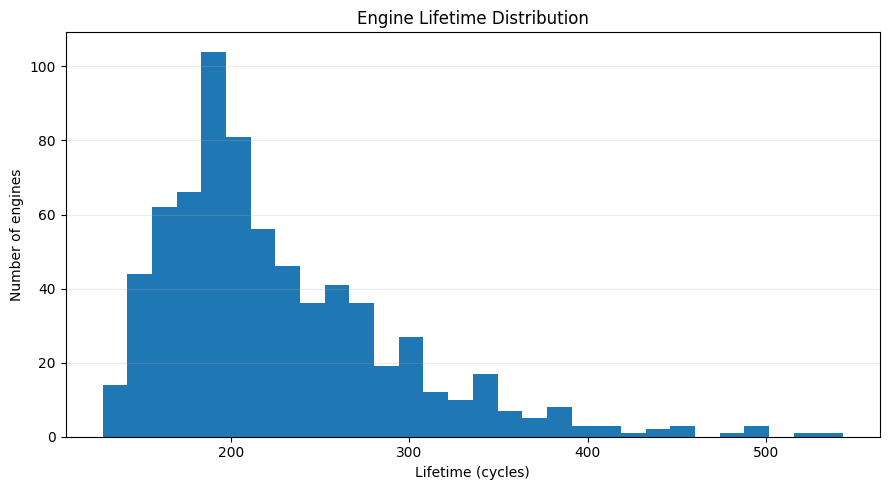

In [7]:
plt.figure(figsize=(9, 5))
plt.hist(engine_lifetime["lifetime"], bins=30)
plt.title("Engine Lifetime Distribution")
plt.xlabel("Lifetime (cycles)")
plt.ylabel("Number of engines")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The lifetime distribution is useful because engines do not all run for the same number of cycles. This is also the basis for constructing the RUL target.

## 5. RUL distribution

In [8]:
df["RUL"].describe()

count   160359.000
mean       122.331
std         83.538
min          0.000
25%         56.000
50%        113.000
75%        172.000
max        542.000
Name: RUL, dtype: float64

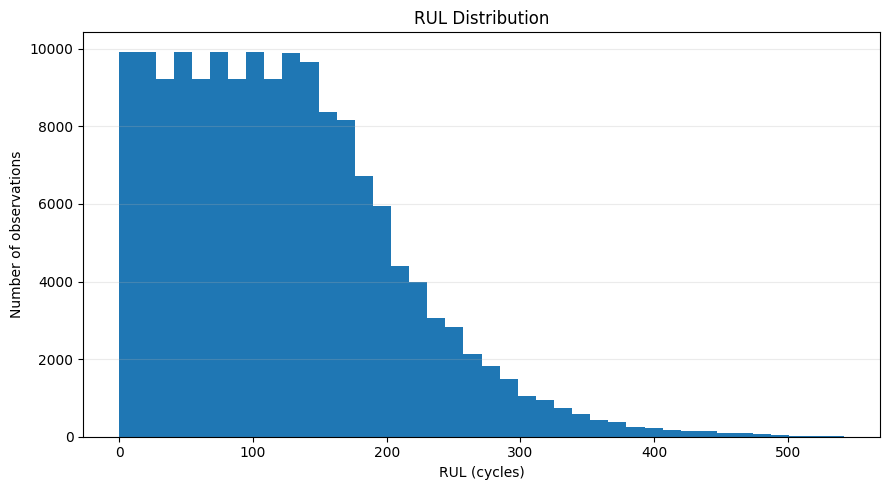

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(df["RUL"], bins=40)
plt.title("RUL Distribution")
plt.xlabel("RUL (cycles)")
plt.ylabel("Number of observations")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Because RUL is calculated from each engine's final observed cycle, early observations generally have larger RUL values while observations close to the end of an engine's life approach zero.

## 6. Sensor behaviour over an engine lifetime

In [10]:
dataset_id = "FD001"
unit_id = 1

engine = df[
    (df["dataset_id"] == dataset_id)
    & (df["unit_id"] == unit_id)
].sort_values("cycle")

print(f"{dataset_id} — Engine {unit_id}")
print(f"Cycles: {engine['cycle'].min()} to {engine['cycle'].max()}")
engine[["cycle", "RUL"]].head()

FD001 — Engine 1
Cycles: 1 to 192


,cycle,RUL
0,1,191
1,2,190
2,3,189
3,4,188
4,5,187


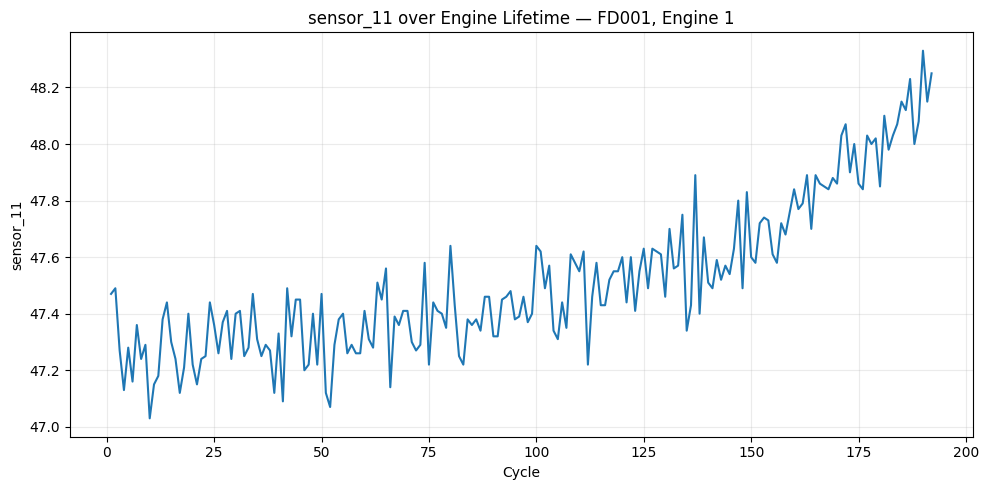

In [11]:
sensor = "sensor_11"

plt.figure(figsize=(10, 5))
plt.plot(engine["cycle"], engine[sensor])
plt.title(f"{sensor} over Engine Lifetime — {dataset_id}, Engine {unit_id}")
plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

A single sensor plot is more useful here than producing 21 nearly identical charts. If a sensor shows a consistent change over cycles, it may contain useful degradation information.

## 7. Sensor correlation with RUL

In [12]:
sensor_columns = [
    column for column in df.columns
    if column.startswith("sensor_")
    and "_lag" not in column
    and "_rolling" not in column
]

correlation = (
    df[sensor_columns + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .to_frame("Correlation")
)

correlation["Absolute_Correlation"] = correlation["Correlation"].abs()

correlation.sort_values(
    "Absolute_Correlation",
    ascending=False,
).head(15)

,Correlation,Absolute_Correlation
sensor_14,-0.065,0.065
sensor_11,-0.045,0.045
sensor_4,-0.032,0.032
sensor_16,-0.031,0.031
sensor_15,-0.029,0.029
sensor_17,-0.021,0.021
sensor_3,-0.020,0.020
sensor_20,0.015,0.015
sensor_21,0.015,0.015
sensor_9,-0.011,0.011


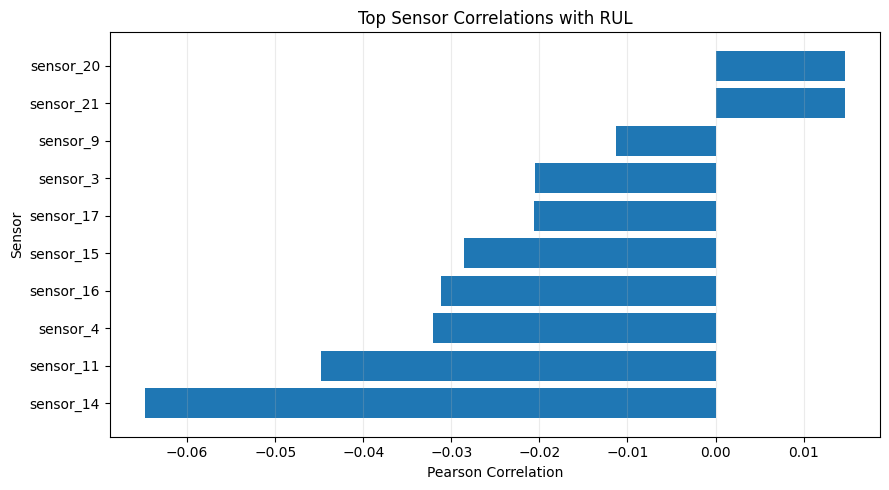

In [13]:
top_corr = correlation.sort_values(
    "Absolute_Correlation",
    ascending=False,
).head(10).sort_values("Correlation")

plt.figure(figsize=(9, 5))
plt.barh(top_corr.index, top_corr["Correlation"])
plt.title("Top Sensor Correlations with RUL")
plt.xlabel("Pearson Correlation")
plt.ylabel("Sensor")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

Correlation is only a first check. A low linear correlation does not necessarily mean that a sensor is useless: degradation can be nonlinear, depend on operating conditions, or become more informative when its recent history is included. This is one reason the project uses lag and rolling features instead of relying only on raw sensor values.

## 8. Feature engineering preview

In [14]:
feature_df = df.copy()

feature_df = remove_constant_columns(feature_df)
feature_df = create_operating_condition(feature_df)
feature_df = add_lag_features(feature_df)
feature_df = add_rolling_features(feature_df)

print(f"Before feature engineering: {df.shape}")
print(f"After feature engineering:  {feature_df.shape}")

feature_df.head()

2026-09-18 01:58:39,619 | INFO | Identified 10 operating conditions
2026-09-18 01:58:39,644 | INFO | Created 21 lag features
2026-09-18 01:58:39,988 | INFO | Created 21 rolling-mean features


Before feature engineering: (160359, 28)
After feature engineering:  (160359, 71)


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,RUL,operating_condition,sensor_1_lag1,sensor_2_lag1,sensor_3_lag1,sensor_4_lag1,sensor_5_lag1,sensor_6_lag1,sensor_7_lag1,sensor_8_lag1,sensor_9_lag1,sensor_10_lag1,sensor_11_lag1,sensor_12_lag1,sensor_13_lag1,sensor_14_lag1,sensor_15_lag1,sensor_16_lag1,sensor_17_lag1,sensor_18_lag1,sensor_19_lag1,sensor_20_lag1,sensor_21_lag1,sensor_1_rolling_mean_3,sensor_2_rolling_mean_3,sensor_3_rolling_mean_3,sensor_4_rolling_mean_3,sensor_5_rolling_mean_3,sensor_6_rolling_mean_3,sensor_7_rolling_mean_3,sensor_8_rolling_mean_3,sensor_9_rolling_mean_3,sensor_10_rolling_mean_3,sensor_11_rolling_mean_3,sensor_12_rolling_mean_3,sensor_13_rolling_mean_3,sensor_14_rolling_mean_3,sensor_15_rolling_mean_3,sensor_16_rolling_mean_3,sensor_17_rolling_mean_3,sensor_18_rolling_mean_3,sensor_19_rolling_mean_3,sensor_20_rolling_mean_3,sensor_21_rolling_mean_3
0,1,1,-0.000,-0.000,100.000,518.670,641.820,1589.700,1400.600,14.620,21.610,554.360,2388.060,9046.190,1.300,47.470,521.660,2388.020,8138.620,8.419,0.030,392,2388,100.000,39.060,23.419,FD001,191,-0.0_-0.0_100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.000,-0.000,100.000,518.670,642.150,1591.820,1403.140,14.620,21.610,553.750,2388.040,9044.070,1.300,47.490,522.280,2388.070,8131.490,8.432,0.030,392,2388,100.000,39.000,23.424,FD001,190,0.0_-0.0_100.0,518.670,641.820,1589.700,1400.600,14.620,21.610,554.360,2388.060,9046.190,1.300,47.470,521.660,2388.020,8138.620,8.419,0.030,392.000,2388.000,100.000,39.060,23.419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.000,0.000,100.000,518.670,642.350,1587.990,1404.200,14.620,21.610,554.260,2388.080,9052.940,1.300,47.270,522.420,2388.030,8133.230,8.418,0.030,390,2388,100.000,38.950,23.344,FD001,189,-0.0_0.0_100.0,518.670,642.150,1591.820,1403.140,14.620,21.610,553.750,2388.040,9044.070,1.300,47.490,522.280,2388.070,8131.490,8.432,0.030,392.000,2388.000,100.000,39.000,23.424,518.670,642.107,1589.837,1402.647,14.620,21.610,554.123,2388.060,9047.733,1.300,47.410,522.120,2388.040,8134.447,8.423,0.030,391.333,2388.000,100.000,39.003,23.396
3,1,4,0.000,0.000,100.000,518.670,642.350,1582.790,1401.870,14.620,21.610,554.450,2388.110,9049.480,1.300,47.130,522.860,2388.080,8133.830,8.368,0.030,392,2388,100.000,38.880,23.374,FD001,188,0.0_0.0_100.0,518.670,642.350,1587.990,1404.200,14.620,21.610,554.260,2388.080,9052.940,1.300,47.270,522.420,2388.030,8133.230,8.418,0.030,390.000,2388.000,100.000,38.950,23.344,518.670,642.283,1587.533,1403.070,14.620,21.610,554.153,2388.077,9048.830,1.300,47.297,522.520,2388.060,8132.850,8.406,0.030,391.333,2388.000,100.000,38.943,23.381
4,1,5,-0.000,-0.000,100.000,518.670,642.370,1582.850,1406.220,14.620,21.610,554.000,2388.060,9055.150,1.300,47.280,522.190,2388.040,8133.800,8.429,0.030,393,2388,100.000,38.900,23.404,FD001,187,-0.0_-0.0_100.0,518.670,642.350,1582.790,1401.870,14.620,21.610,554.450,2388.110,9049.480,1.300,47.130,522.860,2388.080,8133.830,8.368,0.030,392.000,2388.000,100.000,38.880,23.374,518.670,642.357,1584.543,1404.097,14.620,21.610,554.237,2388.083,9052.523,1.300,47.227,522.490,2388.050,8133.620,8.405,0.030,391.667,2388.000,100.000,38.910,23.374


The same feature-engineering functions used by the training/inference pipeline are called here. This avoids maintaining a separate copy of the transformation logic in the notebook.

The main additions are:

- `operating_condition`
- one-cycle lag features
- rolling mean features

The production pipeline later removes rows with missing lag/rolling values before training.

## 9. Quick checks after feature engineering

In [15]:
new_features = sorted(set(feature_df.columns) - set(df.columns))

print(f"New features created: {len(new_features)}")
print(new_features[:20])

print("\nMissing values introduced by time-series features:")
feature_missing = (
    feature_df[new_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

feature_missing[feature_missing > 0].head(10)

New features created: 43
['operating_condition', 'sensor_10_lag1', 'sensor_10_rolling_mean_3', 'sensor_11_lag1', 'sensor_11_rolling_mean_3', 'sensor_12_lag1', 'sensor_12_rolling_mean_3', 'sensor_13_lag1', 'sensor_13_rolling_mean_3', 'sensor_14_lag1', 'sensor_14_rolling_mean_3', 'sensor_15_lag1', 'sensor_15_rolling_mean_3', 'sensor_16_lag1', 'sensor_16_rolling_mean_3', 'sensor_17_lag1', 'sensor_17_rolling_mean_3', 'sensor_18_lag1', 'sensor_18_rolling_mean_3', 'sensor_19_lag1']

Missing values introduced by time-series features:


sensor_10_rolling_mean_3    1418
sensor_12_rolling_mean_3    1418
sensor_11_rolling_mean_3    1418
sensor_14_rolling_mean_3    1418
sensor_13_rolling_mean_3    1418
sensor_21_rolling_mean_3    1418
sensor_20_rolling_mean_3    1418
sensor_17_rolling_mean_3    1418
sensor_18_rolling_mean_3    1418
sensor_16_rolling_mean_3    1418
dtype: int64

The missing values at the beginning of each engine are expected: a lag feature needs a previous cycle and a rolling window needs enough observations. The training pipeline handles these rows explicitly before model fitting.

## 10. Takeaways

Before modelling, the data shows why this is a time-series regression problem rather than a standard tabular regression task:

1. Engines have different operating lifetimes.
2. Sensor behaviour changes over engine cycles.
3. RUL is tied to the position of an engine within its lifetime.
4. Sensor-to-RUL relationships are not necessarily linear.
5. Recent sensor history can provide additional information beyond the current reading.
6. The same feature-engineering code should be reused during training and inference.

The actual model comparison, Optuna tuning, final training and unseen-test evaluation are present in the project's Python pipeline.